# 02. Modelli Supervisionati
In questo notebook addestriamo e confrontiamo tre algoritmi di classificazione: SVM, Random Forest e Logistic Regression. 
Utilizziamo GridSearchCV per trovare i parametri ottimali per ciascun modello.

In [4]:
import os
import sys
import joblib
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Path moduli
sys.path.append(os.path.abspath('modules'))

from models_factory import tune_hyperparameters, save_model, save_results
from visualization import plot_confusion_matrix, plot_pca_2d, plot_pca_3d

SEED = 42

## 1. Caricamento Dati Preprocessati

In [5]:
data = joblib.load('data_processed/processed_data.joblib')
X_pca = data['X_pca']
y_enc = data['y_enc']
class_names = data['classes']

# Split 80/20 stratificato
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc
)

print(f"Train set: {X_train.shape[0]} campioni")
print(f"Test set: {X_test.shape[0]} campioni")

Train set: 640 campioni
Test set: 161 campioni


### 1.1 Visualizzazione Classi Reali (Test Set)
Questo grafico rappresenta la verità del terreno (Ground Truth) a cui i modelli dovrebbero tendere.

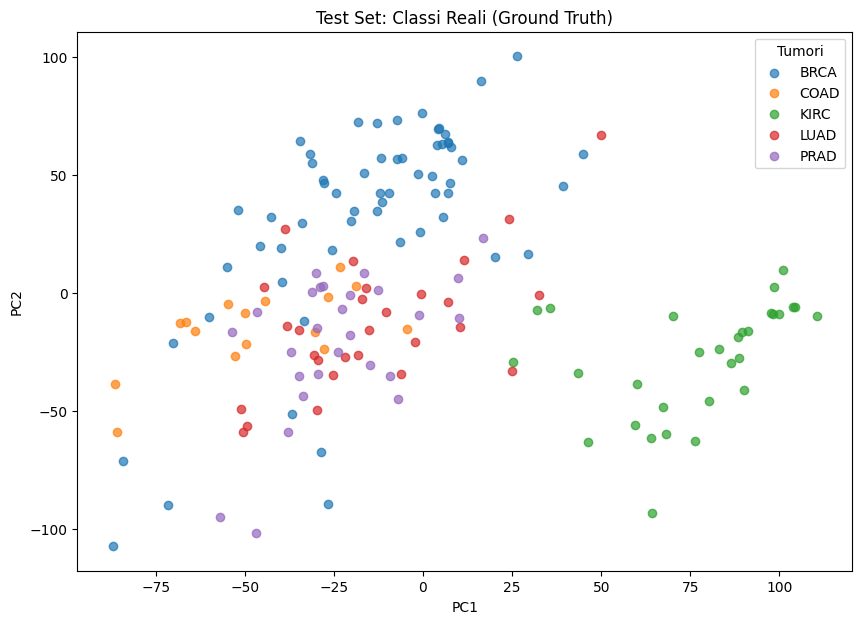

In [6]:
plot_pca_2d(X_test, y_test, class_names, title="Test Set: Classi Reali (Ground Truth)")

## 2. Tuning, Addestramento e Valutazione
Eseguiamo una ricerca a griglia (GridSearchCV) per trovare i migliori parametri per ogni algoritmo.


--- Tuning SVM ---
Migliori parametri: {'C': 0.1, 'kernel': 'linear'}
Accuracy su Test Set: 0.9938
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.96      0.98        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       1.00      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



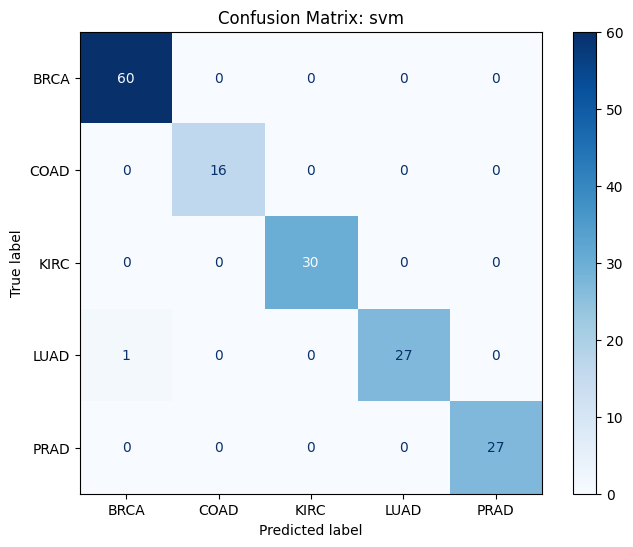

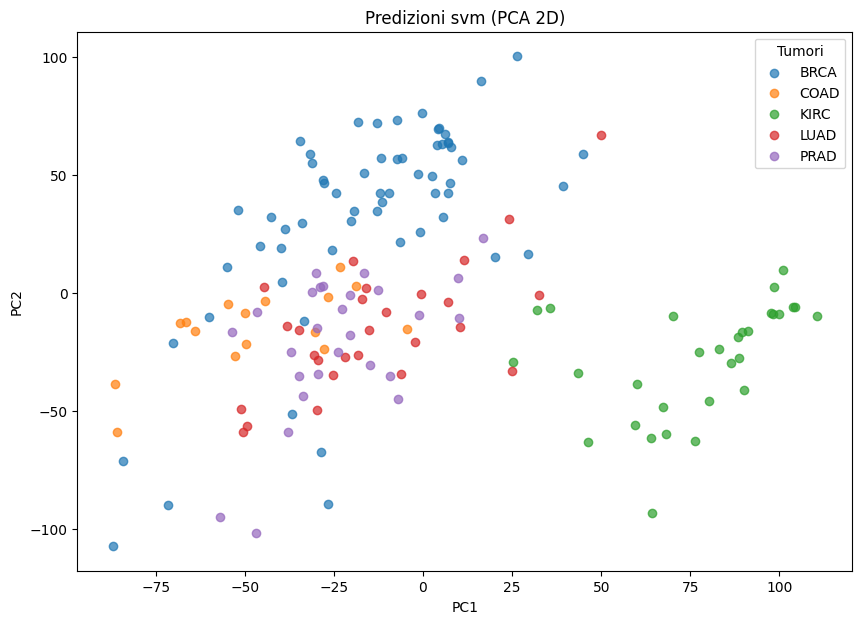


--- Tuning RANDOM_FOREST ---
Migliori parametri: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Accuracy su Test Set: 0.8820
              precision    recall  f1-score   support

        BRCA       0.76      1.00      0.86        60
        COAD       1.00      0.81      0.90        16
        KIRC       1.00      0.90      0.95        30
        LUAD       1.00      0.57      0.73        28
        PRAD       1.00      0.96      0.98        27

    accuracy                           0.88       161
   macro avg       0.95      0.85      0.88       161
weighted avg       0.91      0.88      0.88       161



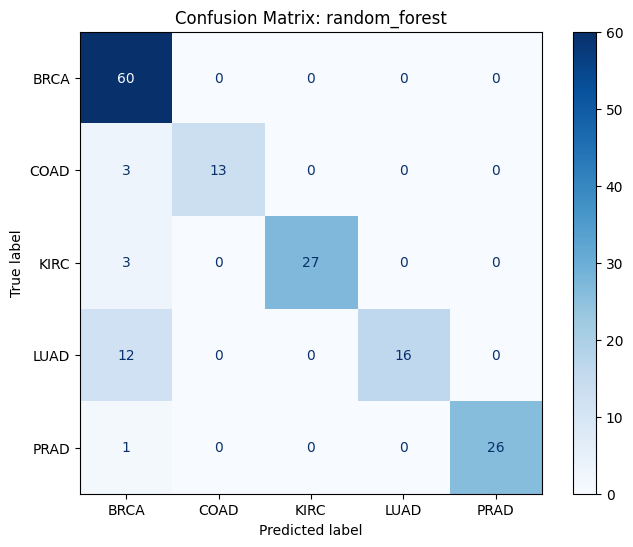

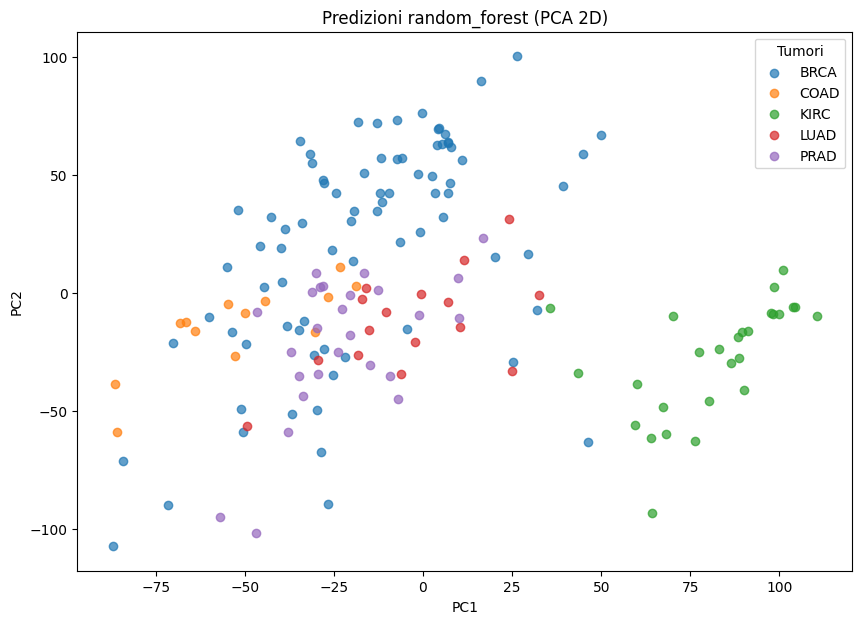


--- Tuning LOGISTIC_REGRESSION ---
Migliori parametri: {'C': 0.1, 'solver': 'lbfgs'}
Accuracy su Test Set: 1.0000
              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      1.00      1.00        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



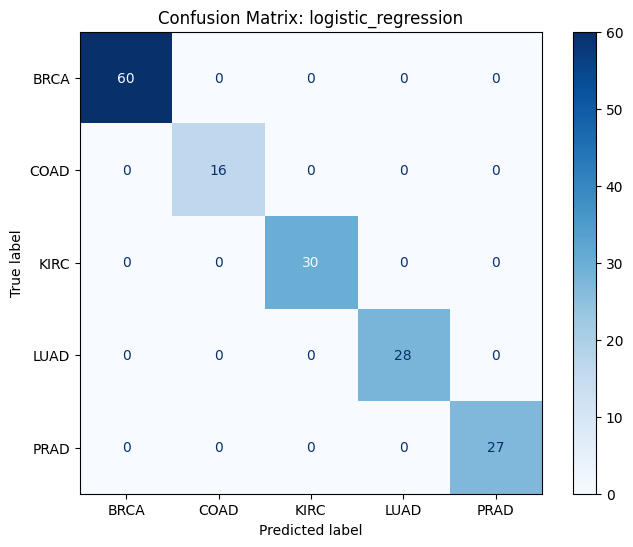

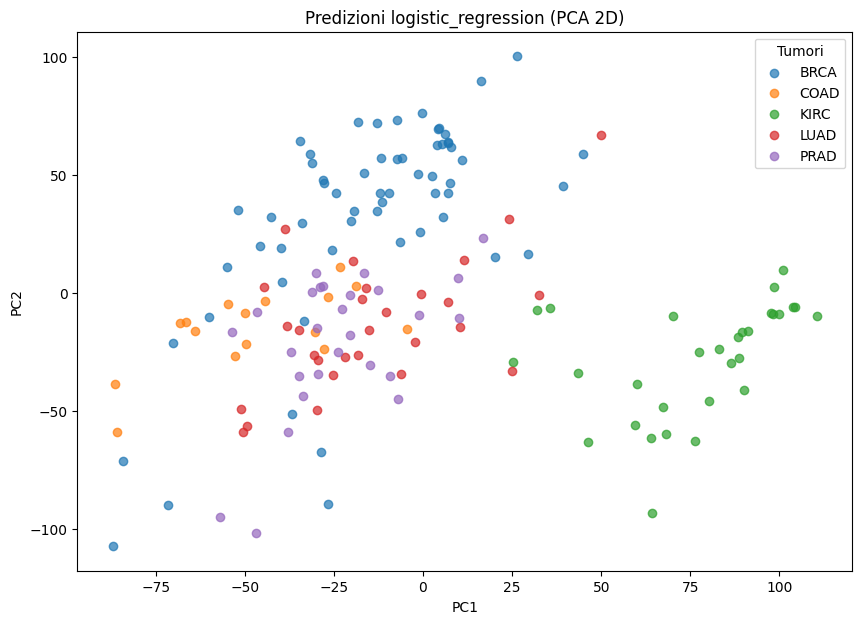


Processo completato.


In [7]:
supervised_algorithms = ['svm', 'random_forest', 'logistic_regression']
best_models = {}

for alg_name in supervised_algorithms:
    print(f"\n--- Tuning {alg_name.upper()} ---")
    
    # Tuning iperparametri
    best_model, best_params = tune_hyperparameters(alg_name, X_train, y_train, seed=SEED)
    print(f"Migliori parametri: {best_params}")
    
    # Valutazione sul Test Set
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Accuracy su Test Set: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    # Visualizzazione Performance
    plot_confusion_matrix(y_test, y_pred, classes=class_names, title=f"Confusion Matrix: {alg_name}")
    
    # Visualizzazione Spaziale delle Predizioni (PCA 2D e 3D)
    plot_pca_2d(X_test, y_pred, class_names, title=f"Predizioni {alg_name} (PCA 2D)")
    
    # Salvataggio
    model_path = save_model(best_model, alg_name)
    save_results({'accuracy': float(acc), 'params': best_params, 'model_path': model_path}, alg_name)
    
    best_models[alg_name] = best_model

print("\nProcesso completato.")